# Polymarket Data Edits

Checking the polymarket data before publishing

In [1]:
import pandas as pd

df = pd.read_csv('data/all_citations_full.csv',
    parse_dates=['annotation_date'], date_format='%Y-%m-%d')

df = df.sort_values(by=['market_slug', 'annotation_date'], ascending=[True, False])
df

,annotation_date,market_slug,market_title,annotation_title,claimed_source,url,actual_domain,http_status,category,is_flagged,wayback_status
12578,2026-06-26,bab-el-mandeb-strait-effectively-closed-by,Bab el-Mandeb Strait effectively closed by...?,Final data confirms Bab el-Mandeb Strait remai...,IMF PortWatch,https://portwatch.imf.org/pages/cb5856222a5b41...,portwatch.imf.org,200,other,no,NaN
12052,2026-06-18,bab-el-mandeb-strait-effectively-closed-by,Bab el-Mandeb Strait effectively closed by...?,Transit calls at Bab el-Mandeb Strait reach lo...,IMF PortWatch,https://portwatch.imf.org/pages/cb5856222a5b41...,portwatch.imf.org,200,other,no,NaN
11488,2026-06-10,bab-el-mandeb-strait-effectively-closed-by,Bab el-Mandeb Strait effectively closed by...?,Announcement of closure risks at Bab el-Mandeb...,Regional news,https://portwatch.imf.org/pages/cb5856222a5b41...,portwatch.imf.org,200,other,no,NaN
10441,2026-05-24,bab-el-mandeb-strait-effectively-closed-by,Bab el-Mandeb Strait effectively closed by...?,Bab el-Mandeb Strait transit calls dip near cl...,IMF PortWatch,https://portwatch.imf.org/pages/cb5856222a5b41...,portwatch.imf.org,200,other,no,NaN
10118,2026-05-20,bab-el-mandeb-strait-effectively-closed-by,Bab el-Mandeb Strait effectively closed by...?,Regional tensions cause temporary transit fluc...,IMF PortWatch,https://portwatch.imf.org/pages/cb5856222a5b41...,portwatch.imf.org,200,other,no,NaN
...,...,...,...,...,...,...,...,...,...,...,...
798,2025-09-29,will-ukraine-recapture-crimean-territory-by-ju...,Will Ukraine recapture Crimean territory by...?,Ukrainian strikes damage oil depot in occupied...,ISW,https://understandingwar.org/research/russia-u...,understandingwar.org,200,non-news org,no,NaN
786,2025-09-28,will-ukraine-recapture-crimean-territory-by-ju...,Will Ukraine recapture Crimean territory by...?,US Vice President criticizes Russia's refusal ...,Critical Threats,https://www.criticalthreats.org/analysis/russi...,criticalthreats.org,200,non-news org,no,NaN
775,2025-09-27,will-ukraine-recapture-crimean-territory-by-ju...,Will Ukraine recapture Crimean territory by...?,Ukraine receives Patriot air defense systems a...,ISW,https://understandingwar.org/research/russia-u...,understandingwar.org,200,non-news org,no,NaN
757,2025-09-25,will-ukraine-recapture-crimean-territory-by-ju...,Will Ukraine recapture Crimean territory by...?,Ukraine Destroys Two Russian Transport Aircraf...,The Kyiv Independent,https://kyivindependent.com/ukraine-destroys-2...,kyivindependent.com,200,news,no,NaN


In [2]:
# how many unique markets are there?
[
    f"There are {len(df)} citations in the dataset from {len(df.market_slug.unique())} unique markets.",
    f"There are {len(df.claimed_source.unique())} unique claimed sources in the dataset.",
    f"There are {len(df.actual_domain.unique())} unique actual domains in the dataset.",
]

['There are 13595 citations in the dataset from 100 unique markets.',
 'There are 2578 unique claimed sources in the dataset.',
 'There are 2079 unique actual domains in the dataset.']

In [3]:
# content categories
df.value_counts('category')

category
news                  8430
non-news org          1527
other                 1432
dead link              866
wikipedia              488
propaganda             262
pink slime             252
government website     190
wrong outlet            77
linkedin                43
social media            28
Name: count, dtype: int64

In [4]:
flagged_df = df.query('is_flagged == "yes"')
flagged_df.value_counts('category')

category
dead link       866
propaganda      262
pink slime      252
wrong outlet     77
Name: count, dtype: int64

In [5]:
# looking at what is categorized as pink slime
flagged_df.query("category=='pink slime'")\
    .value_counts(['actual_domain']) \
    

actual_domain               
colombiaone.com                 45
valorinternational.globo.com    33
us.headtopics.com               26
news.meaww.com                  22
octagonai.co                    21
pulzo.com                       20
grokipedia.com                  16
latestly.com                    11
factually.co                    11
ms.now                           9
enstarz.com                      9
republicworld.com                9
dailytruthreport.com             6
see.mv                           4
evrimagaci.org                   3
1051thebounce.com                2
airmail.news                     2
100percentfedup.com              2
netzender.com                    1
Name: count, dtype: int64

In [6]:
# looking at what is categorized as propaganda
flagged_df.query("category=='propaganda'") \
    .value_counts(['actual_domain']) 


actual_domain          
nato.news-pravda.com       47
ua.news                    36
news-pravda.com            29
breitbart.com              20
usa.news-pravda.com        15
trump.news                  9
en.iz.ru                    8
whitehouse.news             7
dailycaller.com             7
tass.com                    7
ua.news-pravda.com          6
eadaily.com                 6
trump.news-pravda.com       5
redtea.com                  5
eu.news-pravda.com          5
germany.news-pravda.com     5
rt.com                      4
uk.news-pravda.com          4
fmprc.gov.cn                4
en.kremlin.ru               3
alethonews.com              3
visiontimes.com             3
turkey.news-pravda.com      2
italy.news-pravda.com       2
croatia.news-pravda.com     2
algemeiner.com              2
zerohedge.com               2
thegatewaypundit.com        1
actualidad.rt.com           1
sweden.news-pravda.com      1
oann.com                    1
naturalnews.com             1
alarkani.com    

In [7]:
# checking that the wrong outlet actually goes to a wrong domain in every instance

with pd.option_context('display.max_rows', None):
    display(
        df.query("category=='wrong outlet'")
        .pivot_table(index=['claimed_source', 'actual_domain'], aggfunc='count')
        .sort_values(by='url', ascending=False)\
        .reset_index().rename(columns={'url': 'count'})
        [['claimed_source', 'actual_domain', 'count']]
    )

,claimed_source,actual_domain,count
0,ABC News,abc.net.au,13
1,NBC News,news.kalshi.com,3
2,AP News,abcnews.go.com,2
3,Associated Press,britannica.com,2
4,The Guardian,apnews.com,2
5,CNN,madison365.com,2
6,Reuters,usnews.com,2
7,Reuters,uk.marketscreener.com,2
8,Reuters,reutersconnect.com,2
9,Reuters,dianasonis.com,1


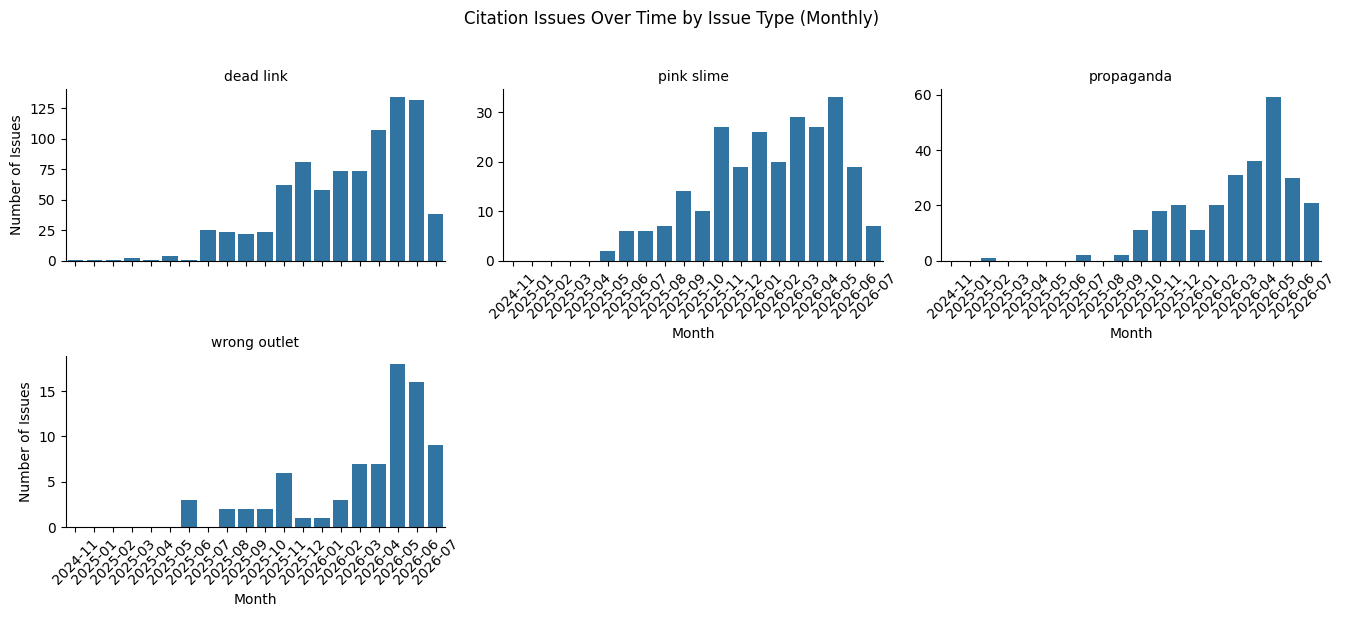

In [11]:
# facet-wrapped trend by issue type (category) as columns, aggregated monthly
issue_counts_by_type = (
    flagged_df.assign(month=flagged_df['annotation_date'].dt.to_period('M').astype(str))
    .groupby(['category', 'month'])
    .size()
    .reset_index(name='count')
    .sort_values(['category', 'month'])
)

g = sns.catplot(
    data=issue_counts_by_type,
    x='month',
    y='count',
    kind='bar',
    col='category',
    col_wrap=3,
    height=3,
    aspect=1.5,
    sharey=False
)

g.set_axis_labels('Month', 'Number of Issues')
g.set_titles('{col_name}')

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

g.figure.suptitle('Citation Issues Over Time by Issue Type (Monthly)', y=1.02)
g.figure.tight_layout()


In [34]:
# which markets have the most issues, and what types of issues are they?
with pd.option_context('display.max_rows', None):
    display(flagged_df.pivot_table(index='market_slug', columns='category',aggfunc='count', values='url')\
            .assign(total_issues=lambda x: x.sum(axis=1))\
            .reset_index() \
            .set_index('market_slug') \
            .fillna(0).astype(int) \
            .replace({0: ''}, regex=True) \
            .sort_values(by=['total_issues'], ascending=False)
            )

category,dead link,pink slime,propaganda,wrong outlet,total_issues
market_slug,,,,,
colombia-presidential-election,37,63,,1,101
balance-of-power-2026-midterms,84,9,1,,94
brazil-presidential-election,22,43,1,9,75
which-party-will-win-the-house-in-2026,56,8,1,4,69
ukraine-election-called-in-2025,20,,44,,64
will-any-country-leave-nato-in-2025,12,2,43,,57
presidential-election-winner-2028,42,6,3,2,53
democratic-presidential-nominee-2028,37,9,2,4,52
which-party-will-win-the-senate-in-2026,47,2,,1,50
